In [1]:
"""
Loading the SMS Spam Collection dataset and checking:
- structure / dtypes
- missing values
- class balance
- duplicate messages
- message length distribution (chars & words) by class
"""

import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("../figures", exist_ok=True) # making folder for features which will be created

In [2]:
# Load the dataset
df = pd.read_csv("../data/raw/SMSSpamCollection.csv", sep="\t", header=None, names=["label", "message"])

print(f"Shape: {df.shape}")

Shape: (5572, 2)


In [3]:
df

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [4]:
# datatypes
df.dtypes

label      str
message    str
dtype: object

In [5]:
# Missing values
df.isnull().sum()

label      0
message    0
dtype: int64

In [6]:
# Class balance
counts = df["label"].value_counts() # spam/ not spam (ham) count
pct = df["label"].value_counts(normalize=True) * 100 # their percentage in the dataset
counts

label
ham     4825
spam     747
Name: count, dtype: int64

In [7]:
pct.round(2)

label
ham     86.59
spam    13.41
Name: proportion, dtype: float64

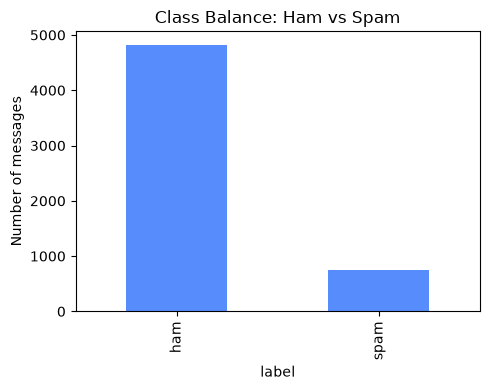

In [8]:
# Class balance figure
fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind="bar", ax=ax)
ax.set_title("Class Balance: Ham vs Spam")
ax.set_ylabel("Number of messages")
plt.tight_layout()
plt.savefig("../figures/class_balance.png", dpi=150)
plt.show()
plt.close()

In [9]:
# Checking duplicates
n_dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {n_dupes} ({n_dupes / len(df):.1%})")


Duplicate rows: 403 (7.2%)


In [10]:
# Message length
df["char_len"] = df["message"].str.len()
df["word_len"] = df["message"].str.split().str.len()
df.groupby("label")["char_len"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.482487,58.440652,2.0,33.0,52.0,93.0,910.0
spam,747.0,138.670683,28.873603,13.0,133.0,149.0,157.0,223.0


In [11]:
print("\nWord count by class:\n", df.groupby("label")["word_len"].describe())


Word count by class:
         count       mean        std  min   25%   50%   75%    max
label                                                            
ham    4825.0  14.310259  11.517945  1.0   7.0  11.0  19.0  171.0
spam    747.0  23.911647   5.780174  2.0  22.0  25.0  28.0   35.0


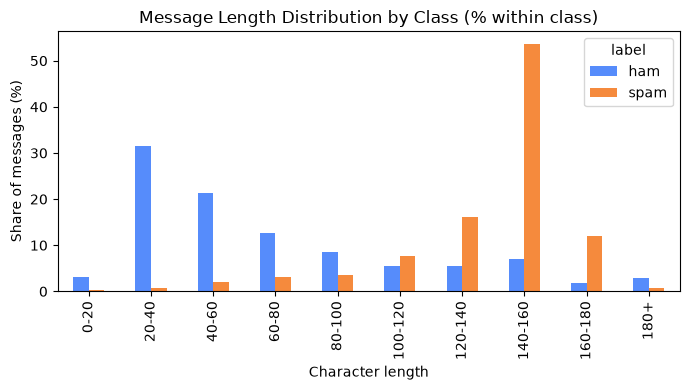

In [12]:
# Message length distribution figure
bins = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 1000]
bin_labels = ["0-20", "20-40", "40-60", "60-80", "80-100", "100-120",
              "120-140", "140-160", "160-180", "180+"]
df["len_bin"] = pd.cut(df["char_len"], bins=bins, labels=bin_labels, right=False)

dist = df.groupby(["len_bin", "label"], observed=True).size().unstack(fill_value=0)
dist_pct = dist.div(dist.sum(axis=0), axis=1) * 100  # normalize within each class

fig, ax = plt.subplots(figsize=(7, 4))
dist_pct.plot(kind="bar", ax=ax)
ax.set_title("Message Length Distribution by Class (% within class)")
ax.set_xlabel("Character length")
ax.set_ylabel("Share of messages (%)")
plt.tight_layout()
plt.savefig("../figures/length_distribution.png", dpi=150)
plt.show()
plt.close()

# Features analysis

In [13]:
# Top words per class
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def tokenize(text):
    # Converts text to lowercase
    # Finds all sequences of 1+ lowercase letters or apostrophes (preserves contractions like "don't")
    # Ignores numbers, spaces, and punctuation (e.g., !, ?, .)
    return re.findall(r"[a-z']+", text.lower())

for lbl in ["ham", "spam"]:
    words = []
    for msg in df.loc[df["label"] == lbl, "message"]:
        words.extend(w for w in tokenize(msg) if w not in ENGLISH_STOP_WORDS and len(w) > 1)
    print(f"\nTop 10 words - {lbl}:")
    for w, c in Counter(words).most_common(10):
        print(f"  {w:12s} {c}")
    print(f"Number of words in {lbl}: {len(words)}")
    print(f"Number of \"gt\" \"lt\" words in {lbl}: {(Counter(words).get("gt") or 0) + (Counter(words).get("lt") or 0)}")


Top 10 words - ham:
  i'm          386
  gt           318
  lt           316
  just         297
  ok           283
  ur           247
  know         237
  good         235
  got          234
  like         234
Number of words in ham: 34541
Number of "gt" "lt" words in ham: 634

Top 10 words - spam:
  free         228
  txt          170
  ur           144
  mobile       129
  stop         128
  text         126
  claim        113
  reply        104
  www          98
  prize        93
Number of words in spam: 10145
Number of "gt" "lt" words in spam: 0


In [14]:
"""Data quality error: unescaped HTML entities used as anonymization placeholders
"&lt;#&gt;" replaces redacted numbers, "&lt;URL&gt;" replaces redacted links, left over
from how the corpus was originally curated. Appears in ~4.5% of ham and 0% of spam here
a curation artifact, not a real spam signal. Left uncleaned it pollutes the
vocabulary with fake tokens "gt", "lt" and also risks the model learning a spurious
split that won't generalize."""

# creating a binary feature flag (1 if message contains '&lt;#&gt;' or '&lt;URL&gt;' placeholders, 0 otherwise)
df["has_placeholder"] = df["message"].str.contains(r"&lt;#&gt;|&lt;URL&gt;", regex=True).astype(int)
# Placeholder artifact by class
df.groupby("label")["has_placeholder"].mean().round(3)

label
ham     0.045
spam    0.000
Name: has_placeholder, dtype: float64

In [15]:
df.groupby("label")["has_placeholder"].sum()

label
ham     217
spam      0
Name: has_placeholder, dtype: int64

In [16]:
# Engineered feature correlation with label
# creating label_bin column, where 1 is spam and 0 is ham
df["label_bin"] = (df["label"] == "spam").astype(int)
# creating char_len column containing length of the mail
df["char_len"] = df["message"].str.len()
# creating word_len column containing length of the words in the mail
df["word_len"] = df["message"].str.split().str.len()
# creating digit_count column containing number of digits in a mail
df["digit_count"] = df["message"].str.count(r"\d")
# creating exclaim column containing number of exclamation marks in a mail
df["exclaim_count"] = df["message"].str.count("!")
# creating currency_count column containing number of currency (£$€) marks in a mail
df["currency_count"] = df["message"].str.count(r"[£$€]")
# creating capital_ratio column containing percentage of capital letters in a mail
df["capital_ratio"] = df["message"].apply(
    lambda x: sum(1 for i in x if i.isupper()) / max(sum(1 for i in x if i.isalpha()), 1)
)

feats = ["char_len", "word_len", "digit_count", "exclaim_count", "currency_count", "capital_ratio"]
corrs = df[feats + ["label_bin"]].corr()["label_bin"].drop("label_bin").sort_values(ascending=False)
print("\nFeature correlation with spam label:", corrs.round(3))


Feature correlation with spam label: digit_count       0.845
currency_count    0.499
char_len          0.382
word_len          0.287
exclaim_count     0.274
capital_ratio     0.203
Name: label_bin, dtype: float64


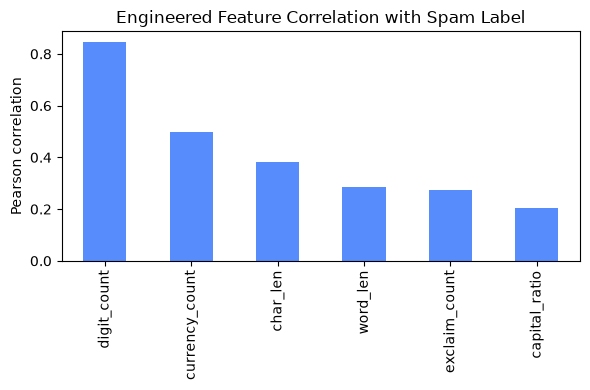

In [17]:
# Engineered Feature Correlation with Spam Label figure creation
fig, ax = plt.subplots(figsize=(6, 4))
corrs.plot(kind="bar", ax=ax)
ax.set_title("Engineered Feature Correlation with Spam Label")
ax.set_ylabel("Pearson correlation")
plt.tight_layout()
plt.savefig("../figures/feature_correlations.png", dpi=150)
plt.show()
plt.close()

In [18]:
# Save
df.to_csv("../dump/sms_with_eda_features.csv", index=False)